# Exploratory Analysis and Data Preparation for a Shopping Products Dataset

**Dataset Used:** Myntra Combined Shopping Dataset containing roughly 1,000 products across 96 categories.

This notebook focuses on understanding the dataset structure, cleaning data quality issues, creating additional analytical features, and extracting useful business insights through visual exploration.

## Step 1: Import Libraries and Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/Combined_dataset.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (1000, 24)

Columns: ['product_id', 'title', 'product_description', 'rating', 'ratings_count', 'initial_price', 'discount', 'final_price', 'currency', 'images', 'delivery_options', 'product_details', 'breadcrumbs', 'product_specifications', 'amount_of_stars', 'what_customers_said', 'seller_name', 'sizes', 'videos', 'seller_information', 'variations', 'best_offer', 'more_offers', 'category']


In [2]:
df.head()

,product_id,title,product_description,rating,ratings_count,initial_price,discount,final_price,currency,images,...,amount_of_stars,what_customers_said,seller_name,sizes,videos,seller_information,variations,best_offer,more_offers,category
0,8376765,Lino Perros,Women Navy Blue Solid Backpack,3.8,15,3995,58.0,"""₹3,995.00""",INR,http://assets.myntassets.com/assets/images/837...,...,"{""1_star"":2,""2_stars"":0,""3_stars"":3,""4_stars"":...",NaN,NaN,"[{""size"":""Onesize""}]","[""rw-8376765_cae700""]",NaN,[{}],{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
1,9136281,Tommy Hilfiger,Unisex Navy Blue Striped Backpack,4.5,67,2899,35.0,"""₹2,899.00""",INR,http://assets.myntassets.com/assets/images/913...,...,"{""1_star"":3,""2_stars"":4,""3_stars"":2,""4_stars"":...",NaN,NaN,"[{""size"":""Onesize""}]","[""rw-9136281_cae700""]",NaN,"[{},{}]",{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
2,17633752,Lavie,Aries Women Pink Mini Backpack,4.4,226,2999,65.0,"""₹2,999.00""",INR,http://assets.myntassets.com/assets/images/176...,...,"{""1_star"":9,""2_stars"":5,""3_stars"":10,""4_stars""...",NaN,NaN,"[{""size"":""S""}]","[""https://videos.myntassets.com/assets/videos/...",NaN,"[{},{},{},{},{},{}]",{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
3,1376949,F Gear,Unisex Navy & Grey Printed Burner Backpack,4.4,1052,1675,52.0,"""₹1,675.00""",INR,http://assets.myntassets.com/assets/images/137...,...,"{""1_star"":33,""2_stars"":21,""3_stars"":69,""4_star...",NaN,NaN,"[{""size"":""Onesize""}]","[""https://videos.myntassets.com/assets/videos/...",NaN,NaN,{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
4,13939916,MYTRIDENT,Men Blue Solid Bath Robe,4.7,12,2899,17.0,"""₹2,899.00""",INR,http://assets.myntassets.com/assets/images/pro...,...,"{""1_star"":0,""2_stars"":0,""3_stars"":0,""4_stars"":...",NaN,NaN,"[{""size"":""M"",""value"":""45.0in"",""value_name"":""Fr...",NaN,NaN,"[{},{},{},{},{},{},{},{},{},{},{},{},{},{}]",{},"[{""offer_name"":""10% Instant Discount on IndusI...",bath-robe


In [3]:
df.tail()

,product_id,title,product_description,rating,ratings_count,initial_price,discount,final_price,currency,images,...,amount_of_stars,what_customers_said,seller_name,sizes,videos,seller_information,variations,best_offer,more_offers,category
995,13698258,KREDO,Men FORTE Silver Automatic Skeleton Analogue W...,3.5,11,11890,50.0,"""₹11,890.00""",INR,http://assets.myntassets.com/assets/images/136...,...,"{""1_star"":3,""2_stars"":0,""3_stars"":2,""4_stars"":...",NaN,NaN,"[{""size"":""Onesize""}]","[""pi-13698258""]",NaN,NaN,{},"[{""offer_name"":""10% Instant Discount on Citi C...",watches
996,16896006,GUESS,Women White Patterned Dial & White Straps Anal...,5.0,22,8900,45.0,"""₹8,900.00""",INR,http://assets.myntassets.com/assets/images/168...,...,"{""1_star"":0,""2_stars"":0,""3_stars"":0,""4_stars"":...",NaN,NaN,"[{""size"":""Onesize""}]","[""rw-16896006_cae700"",""https://videos.myntasse...",NaN,NaN,{},"[{""offer_name"":""10% Instant Discount on Citi C...",watches
997,1708108,GIORDANO,Women Rose Gold-Toned Mirrored Analogue Watch ...,2.8,5,7950,50.0,"""₹7,950.00""",INR,http://assets.myntassets.com/assets/images/170...,...,"{""1_star"":2,""2_stars"":1,""3_stars"":0,""4_stars"":...",NaN,NaN,"[{""size"":""Onesize""}]",NaN,NaN,"[{},{},{},{},{},{},{},{}]",{},"[{""offer_name"":""10% Instant Discount on Citi C...",watches
998,19280114,Fastrack,Men Black Brass Dial & Black Stainless Steel S...,4.3,17,3295,20.0,"""₹2,636.00""",INR,http://assets.myntassets.com/assets/images/192...,...,"{""1_star"":1,""2_stars"":2,""3_stars"":0,""4_stars"":...",NaN,Tru███m R███il,"[{""size"":""Onesize""}]",NaN,Sho███o. ███-10█████████enu███████████████████...,NaN,"{""applicable_on"":""Orders above Rs. 1499 (only ...","[{""offer_name"":""10% Instant Discount on IndusI...",watches
999,18601682,BOLDFIT,Purple Textured Yoga Mat,3.8,161,699,31.0,"""₹699.00""",INR,http://assets.myntassets.com/assets/images/186...,...,"{""1_star"":24,""2_stars"":8,""3_stars"":22,""4_stars...",NaN,NaN,"[{""size"":""Medium""}]",NaN,NaN,"[{},{},{},{}]",{},"[{""offer_name"":""10% Instant Discount on Citi C...",yoga-mats


## Step 2: Explore Dataset Structure and Summary Statistics

In [4]:
df.dtypes

product_id                  int64
title                         str
product_description           str
rating                    float64
ratings_count               int64
initial_price               int64
discount                  float64
final_price                   str
currency                      str
images                        str
delivery_options              str
product_details               str
breadcrumbs                   str
product_specifications        str
amount_of_stars               str
what_customers_said           str
seller_name                   str
sizes                         str
videos                        str
seller_information            str
variations                    str
best_offer                    str
more_offers                   str
category                      str
dtype: object

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   product_id              1000 non-null   int64  
 1   title                   1000 non-null   str    
 2   product_description     1000 non-null   str    
 3   rating                  1000 non-null   float64
 4   ratings_count           1000 non-null   int64  
 5   initial_price           1000 non-null   int64  
 6   discount                879 non-null    float64
 7   final_price             1000 non-null   str    
 8   currency                1000 non-null   str    
 9   images                  1000 non-null   str    
 10  delivery_options        1000 non-null   str    
 11  product_details         1000 non-null   str    
 12  breadcrumbs             1000 non-null   str    
 13  product_specifications  1000 non-null   str    
 14  amount_of_stars         1000 non-null   str    
 15 

In [6]:
df.describe()

,product_id,rating,ratings_count,initial_price,discount
count,1.000000e+03,1000.0000,1000.000000,1000.00000,879.000000
mean,1.713437e+07,3.6215,76.691000,2723.24100,53.503982
std,3.813766e+06,1.3744,241.114263,2408.69736,18.029201
min,5.868460e+05,0.0000,0.000000,249.00000,1.000000
25%,1.511501e+07,3.7000,7.000000,1399.00000,44.000000
50%,1.820890e+07,4.1000,17.000000,1999.00000,56.000000
75%,1.902737e+07,4.3000,58.000000,3299.00000,66.000000
max,2.274707e+07,5.0000,4441.000000,22199.00000,88.000000


In [7]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
product_id                  0
title                       0
product_description         0
rating                      0
ratings_count               0
initial_price               0
discount                  121
final_price                 0
currency                    0
images                      0
delivery_options            0
product_details             0
breadcrumbs                 0
product_specifications      0
amount_of_stars             0
what_customers_said       573
seller_name               301
sizes                       0
videos                    781
seller_information        301
variations                562
best_offer                  0
more_offers                 0
category                    0
dtype: int64


## Step 3: Data Cleaning and Preprocessing

### 3.1 Convert `final_price` into a numeric column by removing currency symbols, commas, and extra characters.

In [8]:
df["final_price"] = (
    df["final_price"]
    .str.replace(r'["₹,]', '', regex=True)
    .str.strip()
    .astype(float)
)

print("final_price dtype:", df["final_price"].dtype)
print(df["final_price"].head())

final_price dtype: float64
0    3995.0
1    2899.0
2    2999.0
3    1675.0
4    2899.0
Name: final_price, dtype: float64


### 3.2 Missing Value Treatment

In [9]:
# discount: 121 nulls — fill with 0 (no discount listed = 0% off)
df["discount"] = df["discount"].fillna(0)

# what_customers_said, seller_name, seller_information, variations, videos:
# these are metadata columns not used in analysis — drop them to keep the dataset clean
cols_to_drop = ["what_customers_said", "videos", "seller_information", "variations"]
df.drop(columns=cols_to_drop, inplace=True)

# seller_name: still has nulls — fill with "Unknown"
df["seller_name"] = df["seller_name"].fillna("Unknown")

print("Remaining nulls:")
print(df.isnull().sum())

Remaining nulls:
product_id                0
title                     0
product_description       0
rating                    0
ratings_count             0
initial_price             0
discount                  0
final_price               0
currency                  0
images                    0
delivery_options          0
product_details           0
breadcrumbs               0
product_specifications    0
amount_of_stars           0
seller_name               0
sizes                     0
best_offer                0
more_offers               0
category                  0
dtype: int64


### 3.3 Duplicate Record Check and Removal

In [10]:
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Rows before: {before} | Rows after: {after} | Dropped: {before - after}")

Rows before: 1000 | Rows after: 1000 | Dropped: 0


### 3.4 Exclude Products Without Valid Ratings

In [11]:
before = len(df)
df = df[df["rating"] > 0].reset_index(drop=True)
print(f"Removed {before - len(df)} unrated products. Remaining: {len(df)}")

Removed 114 unrated products. Remaining: 886


## Step 4: Feature Creation

### 4.1 Generate `price_difference` to measure customer savings.

In [12]:
df["price_difference"] = df["initial_price"] - df["final_price"]
print(df[["title", "initial_price", "final_price", "price_difference"]].head())

            title  initial_price  final_price  price_difference
0     Lino Perros           3995       3995.0               0.0
1  Tommy Hilfiger           2899       2899.0               0.0
2           Lavie           2999       2999.0               0.0
3          F Gear           1675       1675.0               0.0
4       MYTRIDENT           2899       2899.0               0.0


### 4.2 Build a `popularity_metric` using ratings and review volume.

In [13]:
df["popularity_metric"] = df["rating"] * np.log1p(df["ratings_count"])
print(df[["title", "rating", "ratings_count", "popularity_metric"]].head())

            title  rating  ratings_count  popularity_metric
0     Lino Perros     3.8             15          10.535837
1  Tommy Hilfiger     4.5             67          18.987785
2           Lavie     4.4            226          23.869780
3          F Gear     4.4           1052          30.621353
4       MYTRIDENT     4.7             12          12.055262


### 4.3 Estimate `total_amount` using price and review-count based demand approximation.

In [14]:
# The dataset has no quantity column.
# As per the assignment objective (total_amount = price × quantity),
# we use ratings_count as a demand proxy to compute an estimated total amount.
df["total_amount"] = df["final_price"] * df["ratings_count"]
print(df[["title", "final_price", "ratings_count", "total_amount"]].head())

            title  final_price  ratings_count  total_amount
0     Lino Perros       3995.0             15       59925.0
1  Tommy Hilfiger       2899.0             67      194233.0
2           Lavie       2999.0            226      677774.0
3          F Gear       1675.0           1052     1762100.0
4       MYTRIDENT       2899.0             12       34788.0


## Step 5: Data Selection and Filtering Operations

In [15]:
# Filter: products with rating >= 4.5 and discount >= 50%
top_deals = df[(df["rating"] >= 4.5) & (df["discount"] >= 50)][
    ["title", "category", "rating", "discount", "final_price"]
]
print(f"Top deals (rating ≥ 4.5 AND discount ≥ 50%): {len(top_deals)} products")
top_deals.head(10)

Top deals (rating ≥ 4.5 AND discount ≥ 50%): 84 products


,title,category,rating,discount,final_price
7,My Room,bedsheets,4.7,54.0,2999.0
8,My Room,bedsheets,4.5,54.0,2999.0
20,London Rag,boots,5.0,60.0,3839.0
21,The Souled Store,boxers,4.5,54.0,367.0
35,KARATCART,bracelet,4.6,76.0,815.0
44,Zivame,briefs,4.6,50.0,399.0
47,Bruchi CLUB,briefs,5.0,65.0,310.0
66,Clarks,casual-shoes,4.6,50.0,6999.0
70,PUMA Motorsport,casual-shoes,4.5,55.0,4199.0
71,Cortina,chair-cover,4.7,64.0,935.0


In [16]:
# Select: most popular products by popularity_metric
df[["title", "category", "rating", "ratings_count", "popularity_metric"]]    .sort_values("popularity_metric", ascending=False)    .head(10)

,title,category,rating,ratings_count,popularity_metric
127,SASSAFRAS,dresses,4.5,4441,37.794870
103,Athena,dresses,4.2,3797,34.617366
22,Jockey,bra,4.4,1582,32.415139
3,F Gear,backpacks,4.4,1052,30.621353
877,Daniel Klein,watches,4.4,940,30.126550
496,HIGHLANDER,shirts,4.2,1246,29.939683
680,Roadster,sweatshirts,4.3,959,29.527813
219,Mamaearth,face-moisturisers,4.3,903,29.269366
409,Biba,kurta-sets,4.4,749,29.128322
19,Mactree,boots,3.9,1727,29.073408


## Step 6: Exploratory Data Analysis

### 6.1 Distribution Analysis (Single Variable)

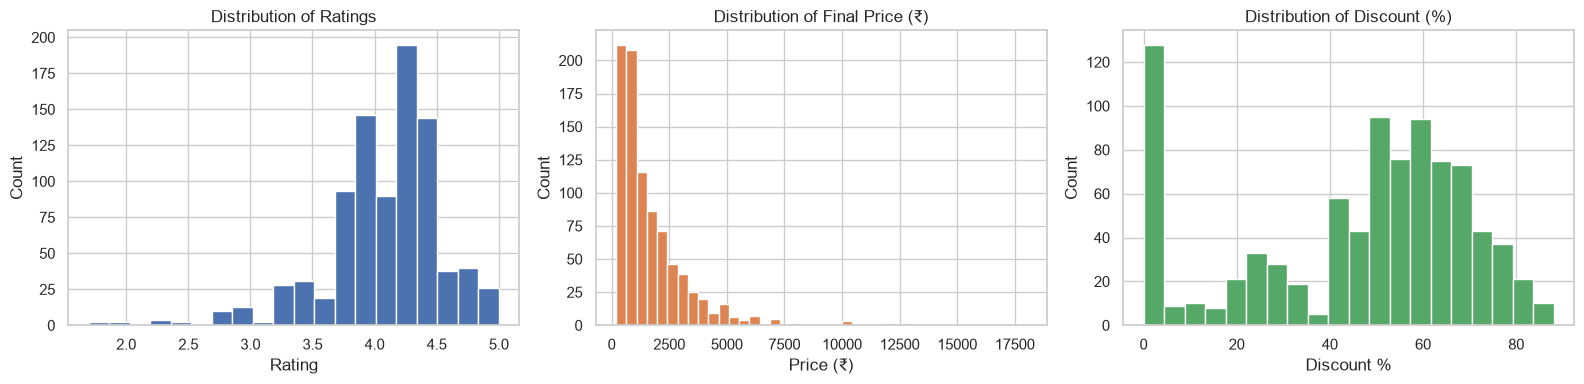

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["rating"], bins=20, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribution of Ratings")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

axes[1].hist(df["final_price"], bins=40, color="#DD8452", edgecolor="white")
axes[1].set_title("Distribution of Final Price (₹)")
axes[1].set_xlabel("Price (₹)")
axes[1].set_ylabel("Count")

axes[2].hist(df["discount"], bins=20, color="#55A868", edgecolor="white")
axes[2].set_title("Distribution of Discount (%)")
axes[2].set_xlabel("Discount %")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig("univariate_analysis.png", bbox_inches="tight")
plt.show()

### 6.2 Relationship Analysis (Two Variables)

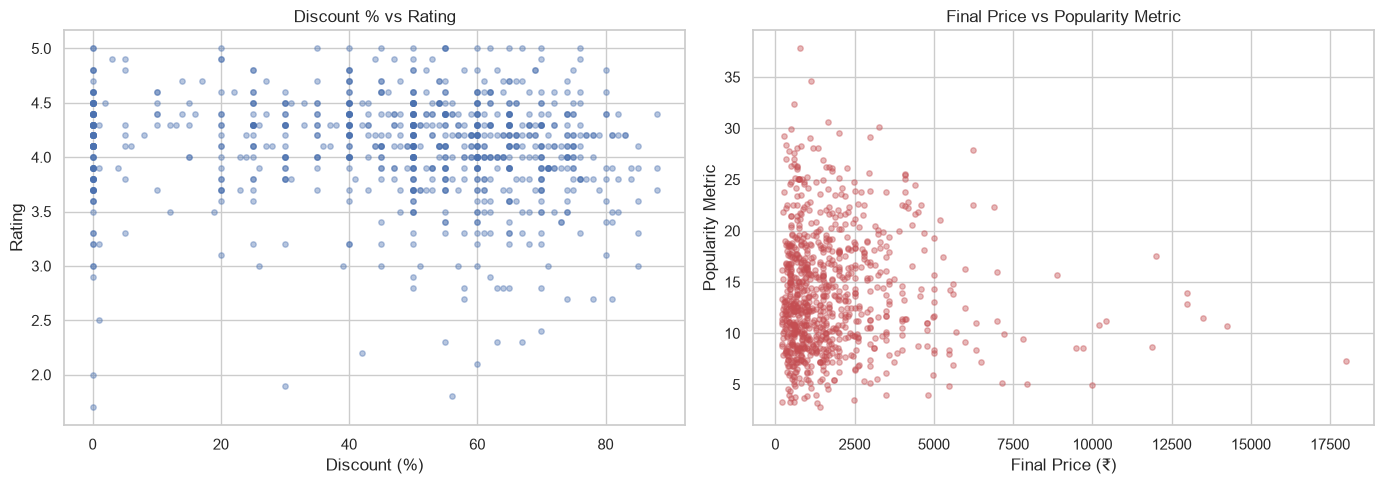

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["discount"], df["rating"], alpha=0.4, color="#4C72B0", s=15)
axes[0].set_title("Discount % vs Rating")
axes[0].set_xlabel("Discount (%)")
axes[0].set_ylabel("Rating")

axes[1].scatter(df["final_price"], df["popularity_metric"], alpha=0.4, color="#C44E52", s=15)
axes[1].set_title("Final Price vs Popularity Metric")
axes[1].set_xlabel("Final Price (₹)")
axes[1].set_ylabel("Popularity Metric")

plt.tight_layout()
plt.savefig("bivariate_analysis.png", bbox_inches="tight")
plt.show()

### 6.3 Performance Comparison Across Categories

In [19]:
category_stats = (
    df.groupby("category")
    .agg(
        avg_rating=("rating", "mean"),
        avg_discount=("discount", "mean"),
        avg_price=("final_price", "mean"),
        product_count=("product_id", "count"),
    )
    .round(2)
    .sort_values("product_count", ascending=False)
)

print("Top 10 categories by product count:")
print(category_stats.head(10).to_string())

Top 10 categories by product count:
                avg_rating  avg_discount  avg_price  product_count
category                                                          
tops                  3.97         45.42    1336.51            106
shirts                4.09         50.06    1392.41             94
dresses               3.96         53.80    1280.82             89
jeans                 4.04         46.26    2231.13             54
sports-shoes          4.12         22.59    4228.47             51
tshirts               4.20         41.53    1067.00             36
sweaters              4.15         39.06    1605.50             34
jackets               4.17         46.08    2587.27             26
earrings              4.23         66.74     662.96             23
ethnic-dresses        3.92         60.50    1272.55             20


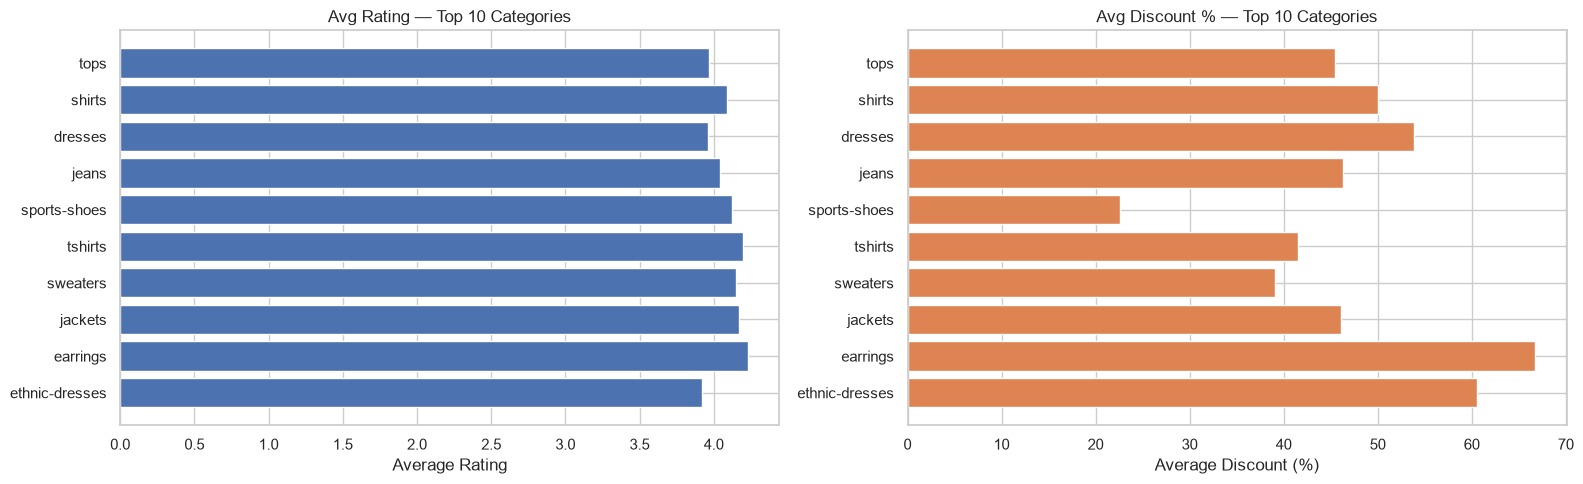

In [20]:
top10 = category_stats.nlargest(10, "product_count")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(top10.index, top10["avg_rating"], color="#4C72B0")
axes[0].set_title("Avg Rating — Top 10 Categories")
axes[0].set_xlabel("Average Rating")
axes[0].invert_yaxis()

axes[1].barh(top10.index, top10["avg_discount"], color="#DD8452")
axes[1].set_title("Avg Discount % — Top 10 Categories")
axes[1].set_xlabel("Average Discount (%)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("category_analysis.png", bbox_inches="tight")
plt.show()

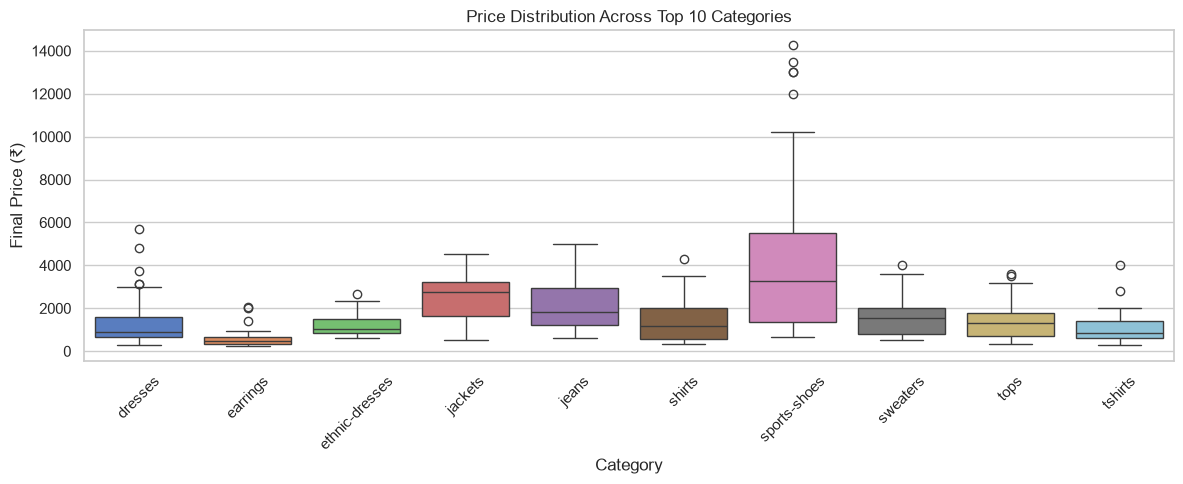

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.boxplot(
    data=df[df["category"].isin(top10.index)],
    x="category",
    y="final_price",
    hue="category",
    palette="muted",
    legend=False,
    ax=ax
)

ax.set_title("Price Distribution Across Top 10 Categories")
ax.set_xlabel("Category")
ax.set_ylabel("Final Price (₹)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("price_boxplot.png", bbox_inches="tight")
plt.show()

## 7: Summary of Findings

1. Product ratings are concentrated in the higher range, suggesting that most listed products receive favorable feedback.
2. Large discounts do not automatically translate into better ratings, indicating that customer satisfaction depends on factors beyond pricing.
3. A small number of categories contribute a substantial share of the product listings.
4. Estimated revenue potential varies considerably across categories because of differences in both pricing and engagement levels.
5. The engineered popularity score helps identify products that combine strong ratings with meaningful customer interaction.

These observations can support pricing analysis, category management, and product recommendation strategies.

## 8: Export the Cleaned Dataset

In [23]:
df.to_csv("../data/Combined_dataset_cleaned.csv", index=False)
print(f"Saved cleaned dataset: {len(df)} rows × {df.shape[1]} columns")
print("Columns:", df.columns.tolist())

Saved cleaned dataset: 886 rows × 23 columns
Columns: ['product_id', 'title', 'product_description', 'rating', 'ratings_count', 'initial_price', 'discount', 'final_price', 'currency', 'images', 'delivery_options', 'product_details', 'breadcrumbs', 'product_specifications', 'amount_of_stars', 'seller_name', 'sizes', 'best_offer', 'more_offers', 'category', 'price_difference', 'popularity_metric', 'total_amount']
